Predicting Market value

Import Libs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")

Load

In [2]:
import pandas as pd

players = pd.read_csv("/content/players.csv")
appearances = pd.read_csv("/content/appearances.csv")
player_valuations = pd.read_csv("/content/player_valuations.csv")
games = pd.read_csv("/content/games.csv")
clubs = pd.read_csv("/content/clubs.csv")
transfers = pd.read_csv("/content/transfers.csv")

Confirm if loaded

In [3]:
print("Players:", players.shape)
print("Appearances:", appearances.shape)
print("Player valuations:", player_valuations.shape)
print("Games:", games.shape)
print("Clubs:", clubs.shape)
print("Transfers:", transfers.shape)

Players: (50149, 26)
Appearances: (1894350, 13)
Player valuations: (656301, 6)
Games: (88958, 23)
Clubs: (796, 17)
Transfers: (175165, 10)


In [4]:
players.head()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus FC,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,IFM,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,Bayern Munich,100000.0,3000000.0


Inspection

In [5]:
print("Players:", players.shape)
print("Appearances:", appearances.shape)
print("Player Valuations:", player_valuations.shape)
print("Games:", games.shape)
print("Clubs:", clubs.shape)
print("Transfers:", transfers.shape)

Players: (50149, 26)
Appearances: (1894350, 13)
Player Valuations: (656301, 6)
Games: (88958, 23)
Clubs: (796, 17)
Transfers: (175165, 10)


Columns

In [6]:
print("PLAYER COLUMNS")
print(players.columns.tolist())

PLAYER COLUMNS
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']


Data Types

In [7]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50149 entries, 0 to 50148
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             50149 non-null  int64  
 1   first_name                            46985 non-null  object 
 2   last_name                             50149 non-null  object 
 3   name                                  50149 non-null  object 
 4   last_season                           50149 non-null  int64  
 5   current_club_id                       50149 non-null  int64  
 6   player_code                           50149 non-null  object 
 7   country_of_birth                      44264 non-null  object 
 8   city_of_birth                         44541 non-null  object 
 9   country_of_citizenship                49880 non-null  object 
 10  date_of_birth                         50100 non-null  object 
 11  sub_position   

Missing values

In [8]:
# Check missing values in all datasets

datasets = {
    "Players": players,
    "Appearances": appearances,
    "Player Valuations": player_valuations,
    "Games": games,
    "Clubs": clubs,
    "Transfers": transfers
}

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"MISSING VALUES - {name}")
    print(f"{'='*60}")

    missing = pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Missing Percentage": (df.isnull().mean() * 100).round(2)
    })

    # Only display columns that contain missing values
    missing = missing[missing["Missing Values"] > 0]

    if missing.empty:
        print("No missing values found.")
    else:
        print(missing.sort_values("Missing Percentage", ascending=False))


MISSING VALUES - Players
                                      Missing Values  Missing Percentage
current_national_team_id                       46889               93.50
international_goals                            30793               61.40
international_caps                             30793               61.40
agent_name                                     23296               46.45
contract_expiration_date                       18569               37.03
market_value_in_eur                             8621               17.19
highest_market_value_in_eur                     8621               17.19
foot                                            5893               11.75
country_of_birth                                5885               11.74
city_of_birth                                   5608               11.18
height_in_cm                                    4365                8.70
first_name                                      3164                6.31
current_club_name        

Missing-value results look reasonable


Do not drop all rows with missing values because some columns have very high missingness and many of those missing values are meaningful.

Data cleaning

Never modify the original dataset directly.

In [9]:
# Create a copy of the Players dataset
players_ml = players.copy()

print("Original shape:", players.shape)
print("Working dataset shape:", players_ml.shape)

Original shape: (50149, 26)
Working dataset shape: (50149, 26)


Our target value being marketvalue.

Remove rows where market value in eur are missing.

CAnnot train a model with missing target variables


In [10]:
# Remove players whose market value is missing
players_ml = players_ml.dropna(subset=["market_value_in_eur"])

print("Shape after removing missing target values:", players_ml.shape)

Shape after removing missing target values: (41528, 26)


In [11]:
removed = len(players) - len(players_ml)

print("Rows removed:", removed)
print("Rows remaining:", len(players_ml))

Rows removed: 8621
Rows remaining: 41528


Drop national team

it has a missing percentage of 93.50%

In [12]:
players_ml = players_ml.drop(
    columns=["current_national_team_id"]
)

print("Column removed successfully.")

Column removed successfully.


Keeping that column offers little to no information

In [13]:
print("current_national_team_id" in players_ml.columns)

False


International goals

REplace their missing value with 0

This is because some players have never represented their nations

This explains the 61% missing values

In [14]:
players_ml["international_goals"] = (
    players_ml["international_goals"].fillna(0)
)

print(
    "Missing international goals:",
    players_ml["international_goals"].isnull().sum()
)

Missing international goals: 0


International caps

Same as the logic behind international goals

In [15]:
players_ml["international_goals"] = (
    players_ml["international_goals"].fillna(0)
)

print(
    "Missing international goals:",
    players_ml["international_goals"].isnull().sum()
)

Missing international goals: 0


Agents

Being a categorical values because of their names

We will replace with unknown

In [16]:
players_ml["agent_name"] = (
    players_ml["agent_name"].fillna("Unknown")
)

print(
    "Missing agent names:",
    players_ml["agent_name"].isnull().sum()
)

Missing agent names: 0


Contract expiration

Replace with unknown

In [17]:
players_ml["contract_expiration_date"] = (
    players_ml["contract_expiration_date"].fillna("Unknown")
)

print(
    "Missing contract expiration dates:",
    players_ml["contract_expiration_date"].isnull().sum()
)

Missing contract expiration dates: 0


Preferred foot

Being categorical data: Right, left or both

we will replace with unknown

In [18]:
players_ml["foot"] = (
    players_ml["foot"].fillna("Unknown")
)

print(
    "Missing foot values:",
    players_ml["foot"].isnull().sum()
)

Missing foot values: 0


Height

Numerical data we can replace missing value with median

In [19]:
median_height = players_ml["height_in_cm"].median()

print("Median height:", median_height)

Median height: 182.0


In [20]:
players_ml["height_in_cm"] = (
    players_ml["height_in_cm"].fillna(median_height)
)

print(
    "Missing height values:",
    players_ml["height_in_cm"].isnull().sum()
)

Missing height values: 0


Using the median is generally safer than using the mean when extreme values exist.

In [21]:
players_ml["country_of_birth"] = (
    players_ml["country_of_birth"].fillna("Unknown")
)

players_ml["city_of_birth"] = (
    players_ml["city_of_birth"].fillna("Unknown")
)

In [22]:
players_ml["country_of_birth"] = (
    players_ml["country_of_birth"].fillna("Unknown")
)

players_ml["city_of_birth"] = (
    players_ml["city_of_birth"].fillna("Unknown")
)

In [23]:
players_ml["first_name"] = (
    players_ml["first_name"].fillna("Unknown")
)

In [24]:
# ==============================
# HANDLE NUMERICAL MISSING VALUES
# ==============================

# International statistics
players_ml["international_goals"] = (
    players_ml["international_goals"].fillna(0)
)

players_ml["international_caps"] = (
    players_ml["international_caps"].fillna(0)
)

# Height - use median
players_ml["height_in_cm"] = (
    players_ml["height_in_cm"].fillna(
        players_ml["height_in_cm"].median()
    )
)

print("Numerical missing values handled.")

Numerical missing values handled.


In [25]:
# Check remaining missing values in numerical columns

numerical_columns = players_ml.select_dtypes(
    include=["int64", "float64"]
).columns

print(players_ml[numerical_columns].isnull().sum())

player_id                      0
last_season                    0
current_club_id                0
height_in_cm                   0
international_caps             0
international_goals            0
market_value_in_eur            0
highest_market_value_in_eur    0
dtype: int64


Why these methods?

International goals/caps:
A missing value can reasonably represent no recorded international appearances/goals, so we use 0.

Height:
Height is continuous numerical data. Using the median avoids removing players and is less affected by extreme values than the mean.

In [26]:
# ==============================
# HANDLE CATEGORICAL MISSING VALUES
# ==============================

categorical_columns = [
    "agent_name",
    "contract_expiration_date",
    "foot",
    "country_of_birth",
    "city_of_birth",
    "first_name",
    "current_club_name",
    "current_club_domestic_competition_id",
    "sub_position",
    "country_of_citizenship"
]

for column in categorical_columns:
    players_ml[column] = players_ml[column].fillna("Unknown")

print("Categorical missing values handled.")

Categorical missing values handled.


In [27]:
# Check remaining missing values in categorical columns

print(
    players_ml[categorical_columns]
    .isnull()
    .sum()
)

agent_name                              0
contract_expiration_date                0
foot                                    0
country_of_birth                        0
city_of_birth                           0
first_name                              0
current_club_name                       0
current_club_domestic_competition_id    0
sub_position                            0
country_of_citizenship                  0
dtype: int64


In [28]:
# ==============================
# REMOVE HIGH-MISSINGNESS COLUMN
# ==============================

players_ml = players_ml.drop(
    columns=["current_national_team_id"],
    errors="ignore"
)

print("current_national_team_id removed.")

current_national_team_id removed.


In [29]:
# ==============================
# HANDLE MISSING TARGET
# ==============================

players_ml = players_ml.dropna(
    subset=["market_value_in_eur"]
)

print(
    "Rows remaining:",
    len(players_ml)
)

Rows remaining: 41528


In [30]:
# ==============================
# HANDLE MISSING DATE OF BIRTH
# ==============================

players_ml = players_ml.dropna(
    subset=["date_of_birth"]
)

print(
    "Rows remaining:",
    len(players_ml)
)

Rows remaining: 41495


In [31]:
# ==============================
# FINAL MISSING VALUE CHECK
# ==============================

missing_summary = pd.DataFrame({
    "Missing Values": players_ml.isnull().sum(),
    "Missing Percentage": (
        players_ml.isnull().mean() * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
]

if missing_summary.empty:
    print("No missing values remain!")
else:
    display(
        missing_summary.sort_values(
            "Missing Percentage",
            ascending=False
        )
    )

No missing values remain!


EDA

Lbz

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Pandas data analysis

NumPy numerical operations

Matplotlib visualizations

In [33]:
print("Number of rows:", players_ml.shape[0])
print("Number of columns:", players_ml.shape[1])

Number of rows: 41495
Number of columns: 25


This tells us how many players and variables remain after cleaning.

In [34]:
display(players_ml.head())

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,contract_expiration_date,agent_name,image_url,international_caps,international_goals,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,Unknown,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,0.0,0.0,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Unknown,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,0.0,0.0,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,Unknown,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,0.0,0.0,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,Unknown,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,Unknown,Unknown,https://img.a.transfermarkt.technology/portrai...,0.0,0.0,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus FC,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,Unknown,IFM,https://img.a.transfermarkt.technology/portrai...,0.0,0.0,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,Bayern Munich,100000.0,3000000.0


In [35]:
print("Columns in the dataset:")
for column in players_ml.columns:
    print(column)

Columns in the dataset:
player_id
first_name
last_name
name
last_season
current_club_id
player_code
country_of_birth
city_of_birth
country_of_citizenship
date_of_birth
sub_position
position
foot
height_in_cm
contract_expiration_date
agent_name
image_url
international_caps
international_goals
url
current_club_domestic_competition_id
current_club_name
market_value_in_eur
highest_market_value_in_eur


In [36]:
players_ml.describe().T

,count,mean,std,min,25%,50%,75%,max
player_id,41495.0,4.327099e+05,3.382849e+05,10.0,149525.5,354792.0,652341.0,1523289.0
last_season,41495.0,2.021240e+03,4.416872e+00,2012.0,2018.0,2024.0,2025.0,2025.0
current_club_id,41495.0,7.822413e+03,1.664593e+04,2.0,467.0,1390.0,6418.0,138189.0
height_in_cm,41495.0,1.820521e+02,7.165574e+00,17.0,178.0,182.0,187.0,210.0
international_caps,41495.0,4.747464e+00,1.387954e+01,0.0,0.0,0.0,2.0,233.0
international_goals,41495.0,5.017472e-01,2.829039e+00,0.0,0.0,0.0,0.0,146.0
market_value_in_eur,41495.0,1.512071e+06,5.856766e+06,10000.0,100000.0,275000.0,700000.0,200000000.0
highest_market_value_in_eur,41495.0,3.451856e+06,9.350661e+06,10000.0,300000.0,750000.0,2500000.0,200000000.0


In [37]:
numerical_columns = players_ml.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = players_ml.select_dtypes(
    include=["object"]
).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['player_id', 'last_season', 'current_club_id', 'height_in_cm', 'international_caps', 'international_goals', 'market_value_in_eur', 'highest_market_value_in_eur']

Categorical columns:
['first_name', 'last_name', 'name', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'contract_expiration_date', 'agent_name', 'image_url', 'url', 'current_club_domestic_competition_id', 'current_club_name']


In [38]:
missing = players_ml.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

Missing values:
Series([], dtype: int64)


In [39]:
duplicates = players_ml.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [40]:
players_ml["market_value_in_eur"].describe()

,market_value_in_eur
count,4.149500e+04
mean,1.512071e+06
std,5.856766e+06
min,1.000000e+04
25%,1.000000e+05
50%,2.750000e+05
75%,7.000000e+05
max,2.000000e+08


Vizzz

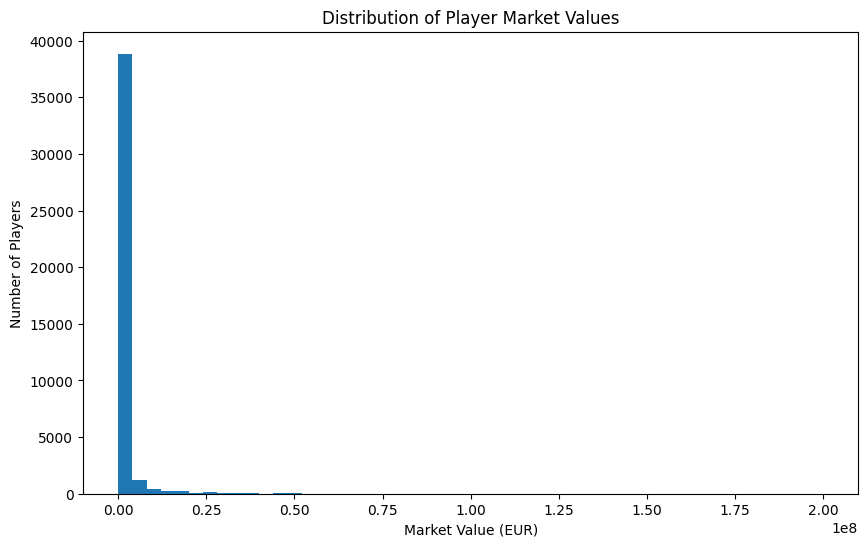

In [41]:
plt.figure(figsize=(10, 6))

plt.hist(
    players_ml["market_value_in_eur"],
    bins=50
)

plt.xlabel("Market Value (EUR)")
plt.ylabel("Number of Players")
plt.title("Distribution of Player Market Values")

plt.show()

Football player market values are usually right-skewed.


That means:

Many players have relatively low values.
A small number of players have extremely high values.

To make it more spread you do a log transformation

Log transformation of market value

In [42]:
players_ml["log_market_value"] = np.log1p(
    players_ml["market_value_in_eur"]
)

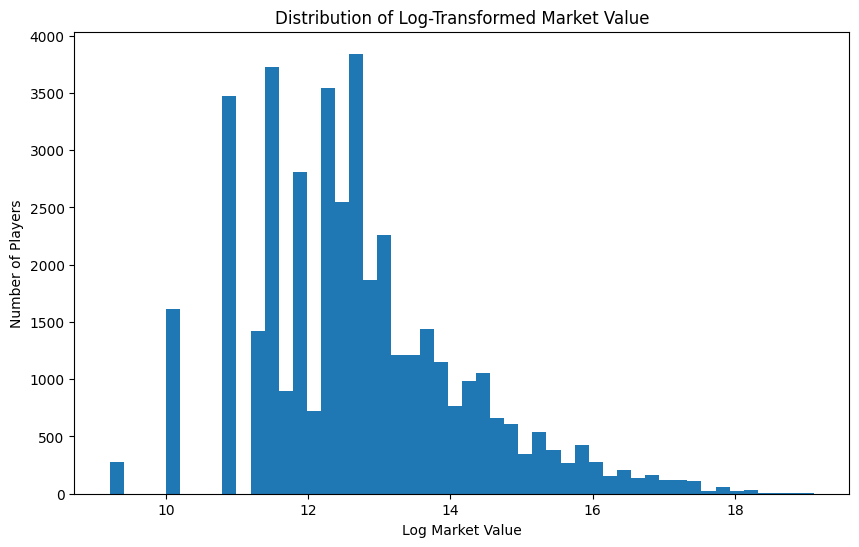

In [43]:
plt.figure(figsize=(10, 6))

plt.hist(
    players_ml["log_market_value"],
    bins=50
)

plt.xlabel("Log Market Value")
plt.ylabel("Number of Players")
plt.title("Distribution of Log-Transformed Market Value")

plt.show()

The transformed distribution should generally be less skewed.

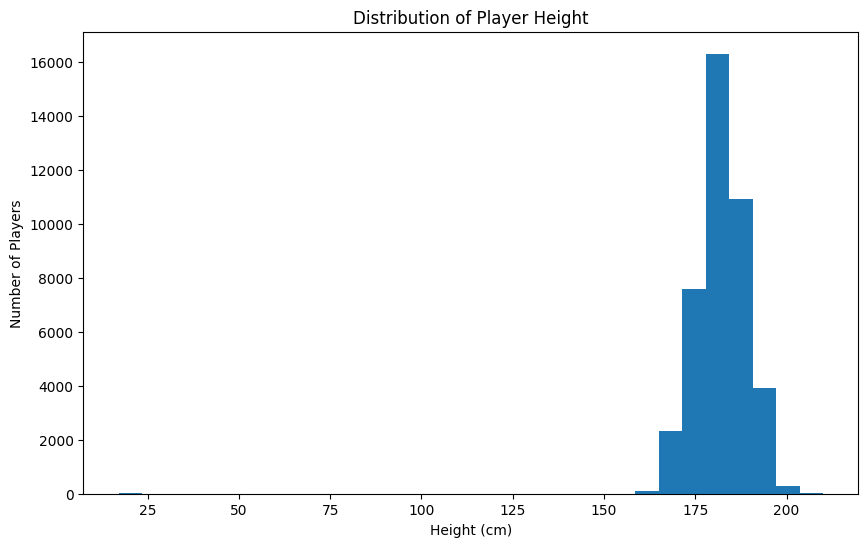

In [44]:
plt.figure(figsize=(10, 6))

plt.hist(
    players_ml["height_in_cm"],
    bins=30
)

plt.xlabel("Height (cm)")
plt.ylabel("Number of Players")
plt.title("Distribution of Player Height")

plt.show()

In [45]:
print(
    "Average height:",
    round(players_ml["height_in_cm"].mean(), 2),
    "cm"
)

print(
    "Median height:",
    players_ml["height_in_cm"].median(),
    "cm"
)

Average height: 182.05 cm
Median height: 182.0 cm


Analyze player position

In [46]:
position_counts = (
    players_ml["sub_position"]
    .value_counts()
    .head(15)
)

display(position_counts)

,count
sub_position,
Centre-Back,7345
Centre-Forward,5696
Central Midfield,4660
Goalkeeper,4602
Defensive Midfield,3485
Right-Back,3118
Left-Back,2940
Attacking Midfield,2899
Left Winger,2742


Vizzz

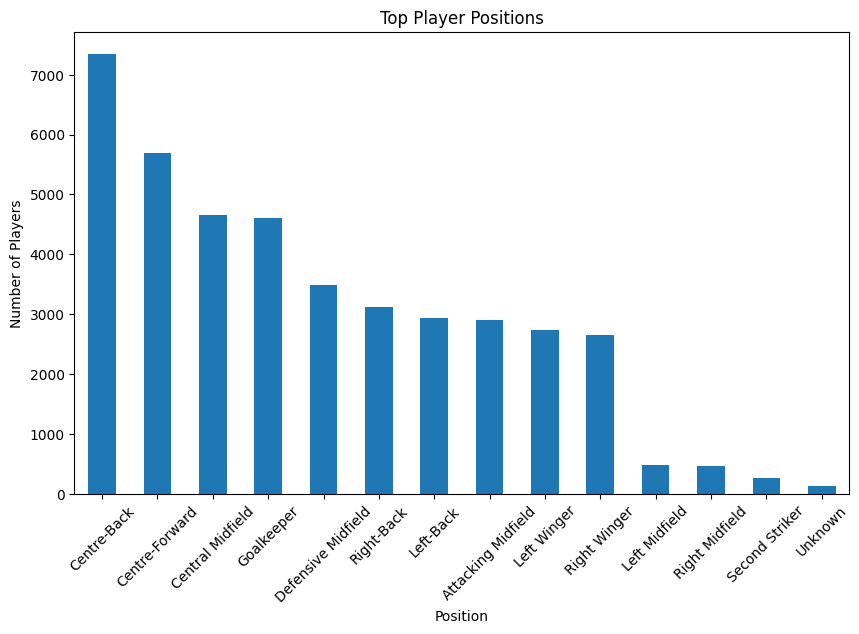

In [47]:
plt.figure(figsize=(10, 6))

position_counts.plot(kind="bar")

plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.title("Top Player Positions")

plt.xticks(rotation=45)

plt.show()

Preferred foot

In [48]:
foot_counts = players_ml["foot"].value_counts()

display(foot_counts)

,count
foot,
right,27230
left,9509
Unknown,3128
both,1628


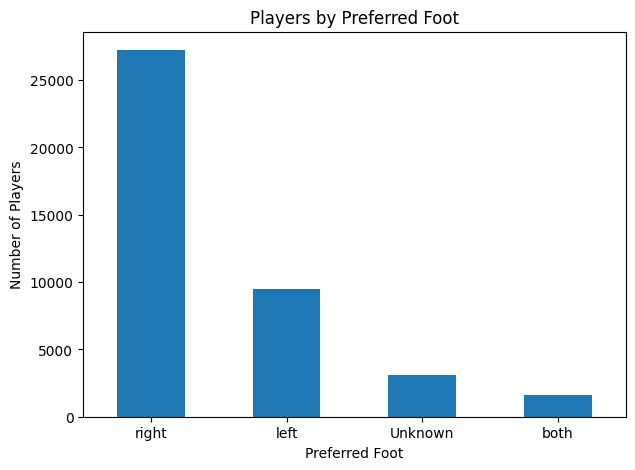

In [49]:
plt.figure(figsize=(7, 5))

foot_counts.plot(kind="bar")

plt.xlabel("Preferred Foot")
plt.ylabel("Number of Players")
plt.title("Players by Preferred Foot")

plt.xticks(rotation=0)

plt.show()

Analyze player age

In [50]:
players_ml["date_of_birth"] = pd.to_datetime(
    players_ml["date_of_birth"],
    errors="coerce"
)

reference_date = pd.Timestamp.today()

players_ml["age"] = (
    (reference_date - players_ml["date_of_birth"])
    .dt.days / 365.25
)

players_ml["age"] = players_ml["age"].round(1)

players_ml[["date_of_birth", "age"]].head()

,date_of_birth,age
0,1978-06-09,48.3
1,1980-08-06,46.1
2,1981-01-30,45.6
3,1978-05-08,48.4
4,1981-03-18,45.5


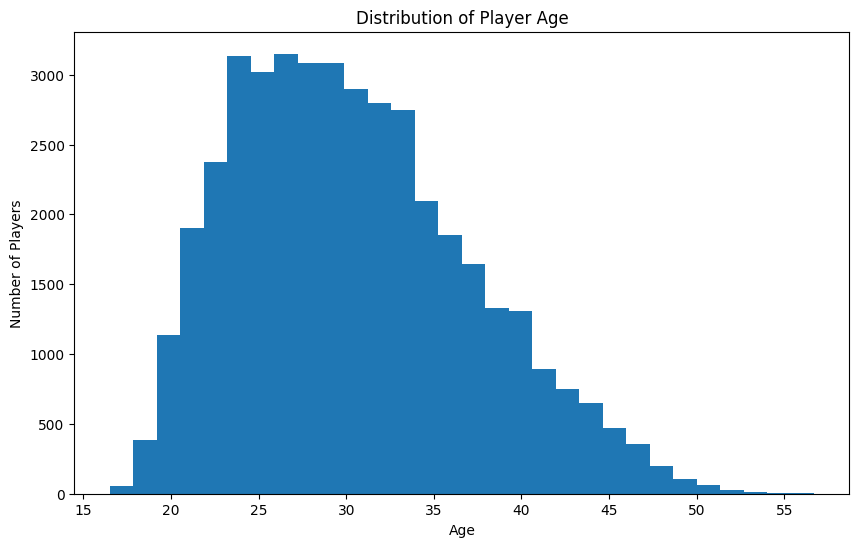

In [51]:
plt.figure(figsize=(10, 6))

plt.hist(
    players_ml["age"],
    bins=30
)

plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.title("Distribution of Player Age")

plt.show()

Age vs Market Value

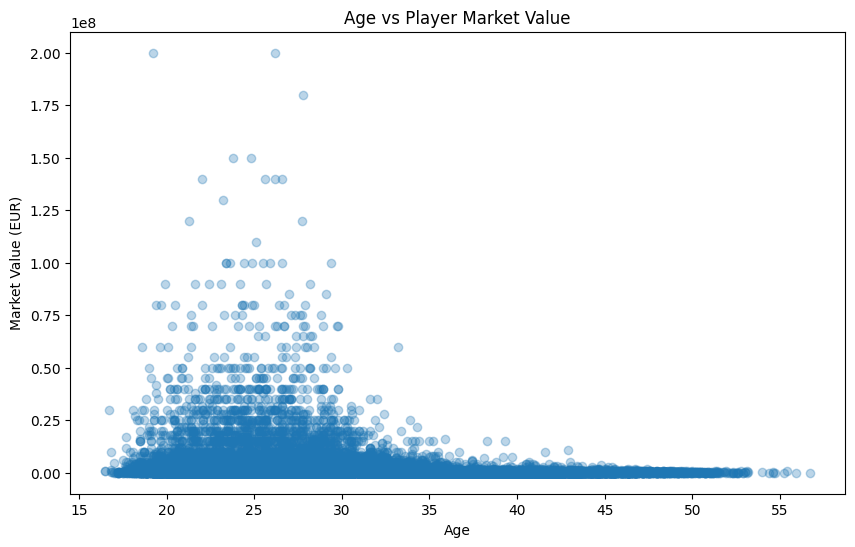

In [52]:
plt.figure(figsize=(10, 6))

plt.scatter(
    players_ml["age"],
    players_ml["market_value_in_eur"],
    alpha=0.3
)

plt.xlabel("Age")
plt.ylabel("Market Value (EUR)")
plt.title("Age vs Player Market Value")

plt.show()

Theres some skew noticed

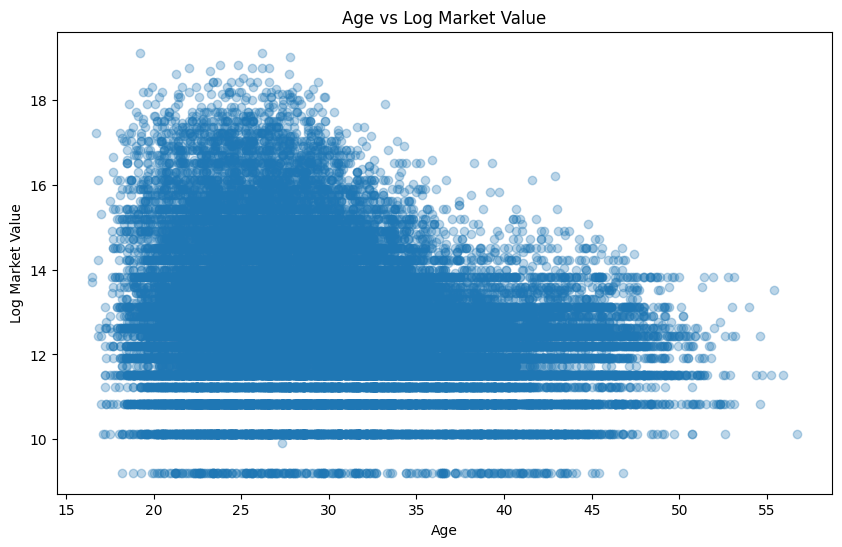

In [53]:
plt.figure(figsize=(10, 6))

plt.scatter(
    players_ml["age"],
    players_ml["log_market_value"],
    alpha=0.3
)

plt.xlabel("Age")
plt.ylabel("Log Market Value")
plt.title("Age vs Log Market Value")

plt.show()

Log transformation to clearly define relationships without the skew

In [54]:
players_ml["international_caps"].describe()

,international_caps
count,41495.000000
mean,4.747464
std,13.879539
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,233.000000


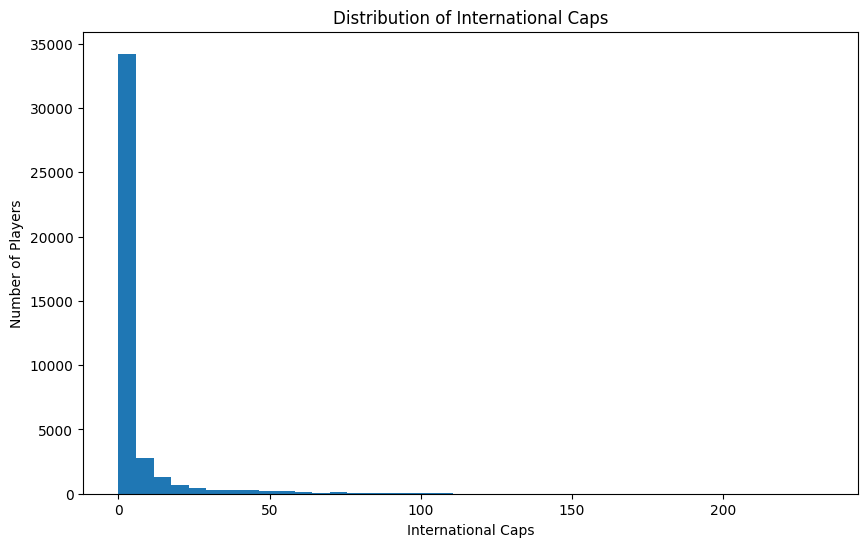

In [55]:
plt.figure(figsize=(10, 6))

plt.hist(
    players_ml["international_caps"],
    bins=40
)

plt.xlabel("International Caps")
plt.ylabel("Number of Players")
plt.title("Distribution of International Caps")

plt.show()

In [56]:
# Check skewness of international caps

skewness = players_ml["international_caps"].skew()

print("Skewness of international caps:", skewness)

Skewness of international caps: 5.134353859244263


In [57]:
# Skewness of numerical variables

skewness = players_ml[numerical_columns].skew()

display(
    skewness.sort_values(ascending=False)
)

,0
international_goals,16.745689
market_value_in_eur,11.750112
highest_market_value_in_eur,7.446665
international_caps,5.134354
current_club_id,3.605294
player_id,0.750446
last_season,-0.775873
height_in_cm,-3.206448


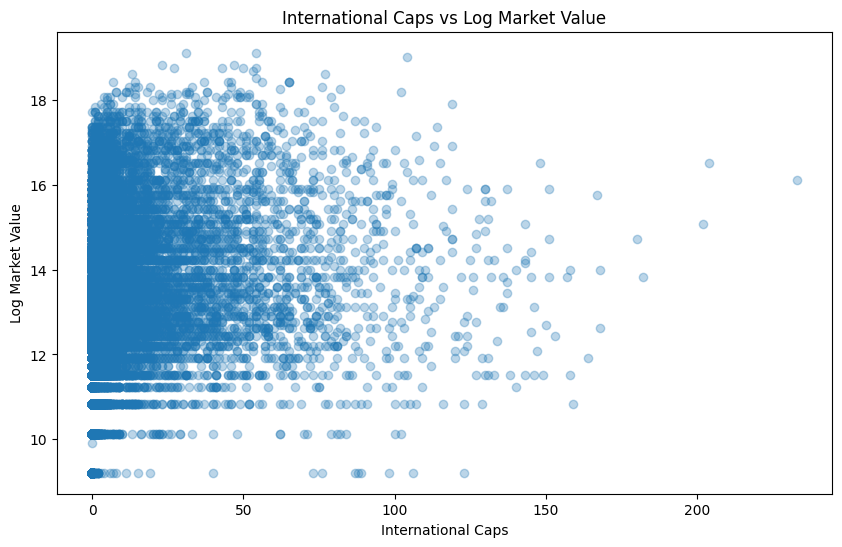

In [58]:
plt.figure(figsize=(10, 6))

plt.scatter(
    players_ml["international_caps"],
    players_ml["log_market_value"],
    alpha=0.3
)

plt.xlabel("International Caps")
plt.ylabel("Log Market Value")
plt.title("International Caps vs Log Market Value")

plt.show()

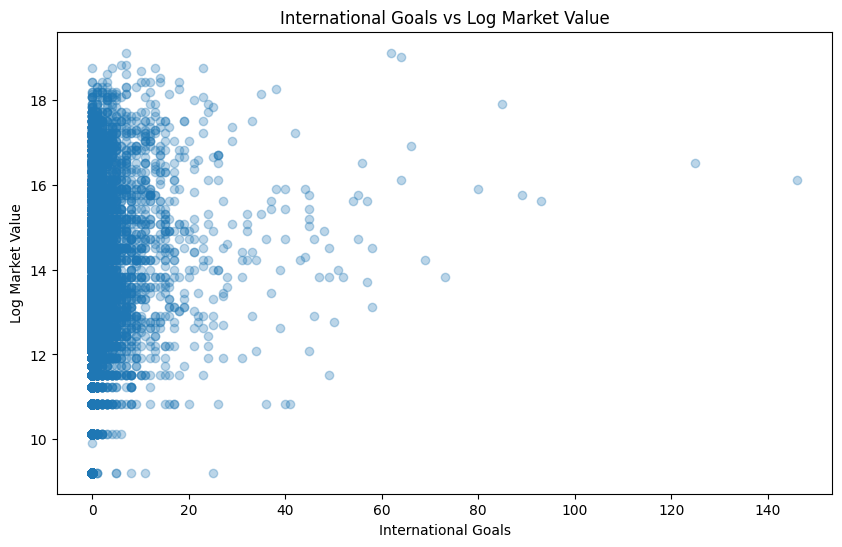

In [59]:
plt.figure(figsize=(10, 6))

plt.scatter(
    players_ml["international_goals"],
    players_ml["log_market_value"],
    alpha=0.3
)

plt.xlabel("International Goals")
plt.ylabel("Log Market Value")
plt.title("International Goals vs Log Market Value")

plt.show()

Correlation analysis

In [60]:
correlation_matrix = players_ml[
    numerical_columns
].corr()

display(correlation_matrix)

,player_id,last_season,current_club_id,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur
player_id,1.000000,0.575275,0.149960,-0.027666,-0.040424,-0.025842,0.098128,-0.081656
last_season,0.575275,1.000000,0.191579,0.014597,0.285278,0.147919,0.182422,0.147944
current_club_id,0.149960,0.191579,1.000000,-0.055118,0.059251,0.018473,-0.066328,-0.088188
height_in_cm,-0.027666,0.014597,-0.055118,1.000000,-0.020945,-0.021652,0.013157,0.001498
international_caps,-0.040424,0.285278,0.059251,-0.020945,1.000000,0.649059,0.239006,0.410013
international_goals,-0.025842,0.147919,0.018473,-0.021652,0.649059,1.000000,0.224850,0.415293
market_value_in_eur,0.098128,0.182422,-0.066328,0.013157,0.239006,0.224850,1.000000,0.757221
highest_market_value_in_eur,-0.081656,0.147944,-0.088188,0.001498,0.410013,0.415293,0.757221,1.000000


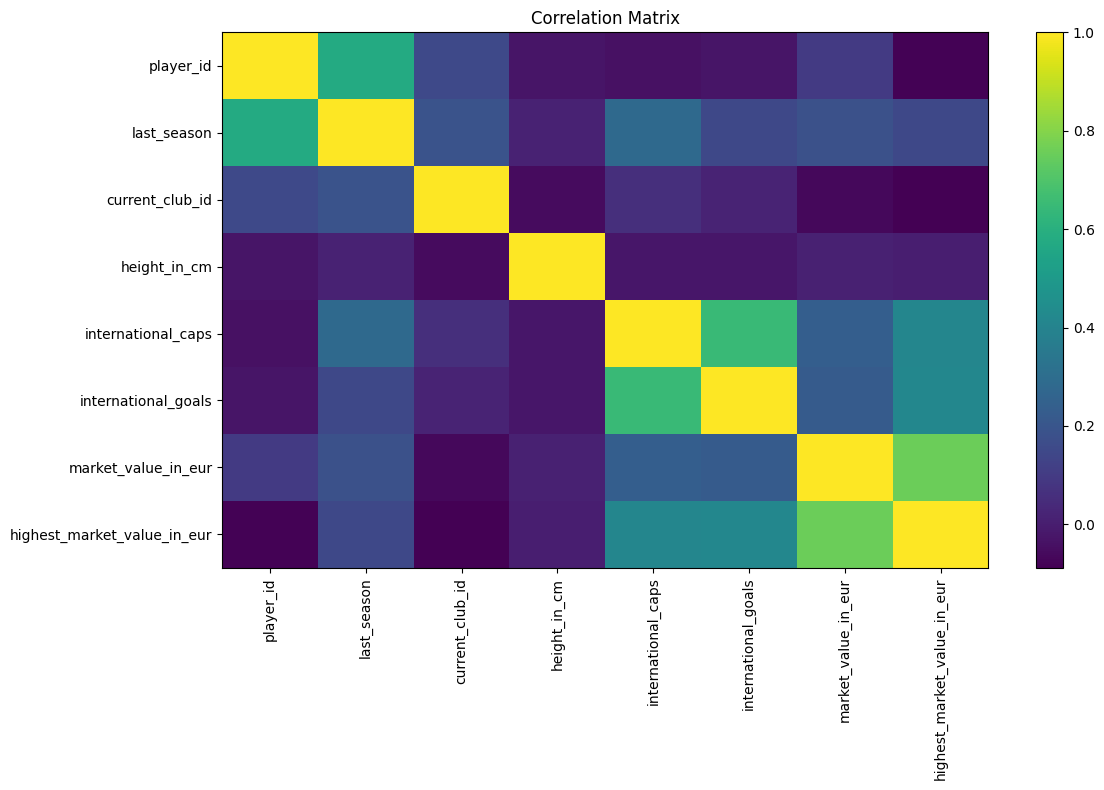

In [61]:
plt.figure(figsize=(12, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

SInce market value is our target

Check variable highly relared to t

In [62]:
market_value_corr = (
    correlation_matrix["market_value_in_eur"]
    .sort_values(ascending=False)
)

display(market_value_corr)

,market_value_in_eur
market_value_in_eur,1.000000
highest_market_value_in_eur,0.757221
international_caps,0.239006
international_goals,0.224850
last_season,0.182422
player_id,0.098128
height_in_cm,0.013157
current_club_id,-0.066328


In [63]:
top_players = players_ml[
    [
        "first_name",
        "last_name",
        "current_club_name",
        "sub_position",
        "age",
        "market_value_in_eur"
    ]
].sort_values(
    "market_value_in_eur",
    ascending=False
).head(10)

display(top_players)

,first_name,last_name,current_club_name,sub_position,age,market_value_in_eur
41232,Unknown,Lamine Yamal,FC Barcelona,Right Winger,19.2,200000000.0
24702,Erling,Haaland,Manchester City,Centre-Forward,26.2,200000000.0
20934,Kylian,Mbappé,Real Madrid,Centre-Forward,27.8,180000000.0
34715,Unknown,Pedri,FC Barcelona,Central Midfield,23.8,150000000.0
30257,Michael,Olise,Bayern Munich,Right Winger,24.8,150000000.0
27300,Unknown,Vitinha,Paris Saint-Germain,Defensive Midfield,26.6,140000000.0
34296,João,Neves,Paris Saint-Germain,Central Midfield,22.0,140000000.0
22532,Unknown,Vinicius Junior,Real Madrid,Left Winger,26.2,140000000.0
27839,Khvicha,Kvaratskhelia,Paris Saint-Germain,Left Winger,25.6,140000000.0
30887,Jude,Bellingham,Real Madrid,Attacking Midfield,23.2,130000000.0


Market value vs Position

In [64]:
position_market_value = (
    players_ml
    .groupby("sub_position")["market_value_in_eur"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

display(position_market_value)

,count,mean,median
sub_position,,,
Left Winger,2742,2.015024e+06,350000.0
Attacking Midfield,2899,1.963727e+06,300000.0
Centre-Back,7345,1.504446e+06,300000.0
Defensive Midfield,3485,1.523055e+06,300000.0
Left-Back,2940,1.318770e+06,300000.0
Central Midfield,4660,1.775678e+06,300000.0
Right-Back,3118,1.259713e+06,300000.0
Right Winger,2660,2.015133e+06,300000.0
Right Midfield,473,8.643446e+05,250000.0


Why use the median?

Market values have extreme outliers.

For example, one superstar worth €150 million can dramatically increase the mean of a position.

The median gives us a better idea of the typical player value.

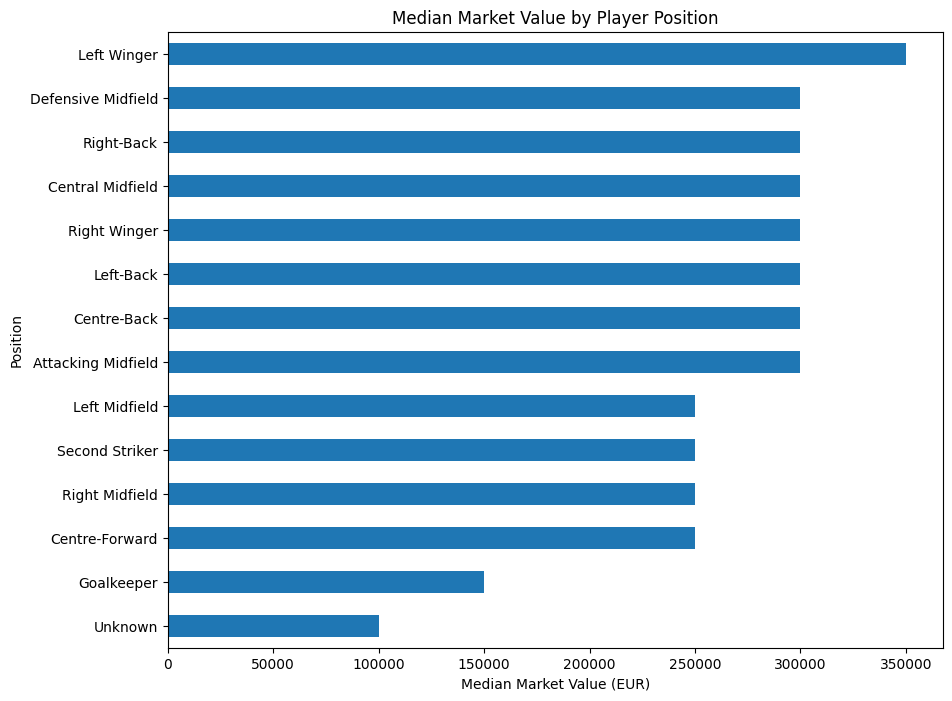

In [65]:
position_market_value["median"].sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.xlabel("Median Market Value (EUR)")
plt.ylabel("Position")
plt.title("Median Market Value by Player Position")

plt.show()

Identiift outliers

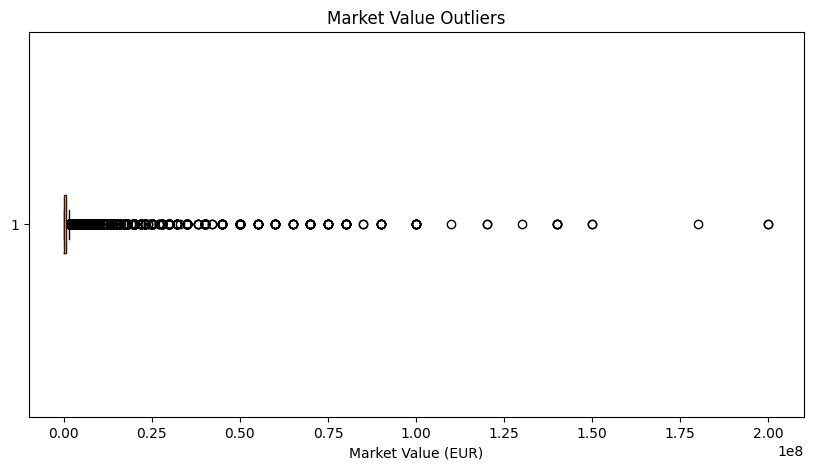

In [66]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    players_ml["market_value_in_eur"],
    vert=False
)

plt.xlabel("Market Value (EUR)")
plt.title("Market Value Outliers")

plt.show()

EDA Summary

Market value is highly right-skewed, with a small number of players having very high values.

A log transformation makes the distribution more manageable for analysis.
Player age is an important variable to investigate because market value can vary substantially across different age groups.

Player position may influence market value because different positions have different market demand.

International caps and goals provide measures of international experience.

Player height shows a numerical characteristic that can be evaluated against market value.

The correlation analysis helps identify numerical variables that may be useful predictors.

There are significant outliers in market value, which need to be considered when training regression models.

**Feature engineering**

In [67]:
# Define target variable

target = "market_value_in_eur"

X = players_ml.drop(columns=[target])
y = players_ml[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (41495, 26)
Target shape: (41495,)


In [68]:
# Remove columns that should not be used as predictors

columns_to_drop = [
    "player_id",
    "first_name",
    "last_name",
    "player_code",
    "current_club_name",
    "agent_name",
    "city_of_birth",
    "date_of_birth",
    "contract_expiration_date",
    "log_market_value"
]

X = X.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print("Remaining features:")
print(X.columns.tolist())

Remaining features:
['name', 'last_season', 'current_club_id', 'country_of_birth', 'country_of_citizenship', 'sub_position', 'position', 'foot', 'height_in_cm', 'image_url', 'international_caps', 'international_goals', 'url', 'current_club_domestic_competition_id', 'highest_market_value_in_eur', 'age']


Some columns are identifiers, names, or information that isn't appropriate as a direct model feature.

In [69]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['last_season', 'current_club_id', 'height_in_cm', 'international_caps', 'international_goals', 'highest_market_value_in_eur', 'age']

Categorical features:
['name', 'country_of_birth', 'country_of_citizenship', 'sub_position', 'position', 'foot', 'image_url', 'url', 'current_club_domestic_competition_id']


Train Test split

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (33196, 16)
Testing set: (8299, 16)


Pre-processing pipelines

In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [72]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

Fills any missing numerical values using the median.
Standardizes numerical features.

In [73]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

Fills missing categorical values.

Converts categories into numerical values using one-hot encoding.

Combiine pre processing pipelins

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


Base model-Linear regression

Train

In [75]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


Predictions

In [76]:
y_pred_linear = linear_model.predict(X_test)

print("First 10 predictions:")
print(y_pred_linear[:10])

First 10 predictions:
[ 1290801.77332526    42692.44463381  -613860.14744742  1921311.35677578
  7816683.34830257  2909063.25936503   350595.78211119   839643.57067442
 -1879037.68593439  2607569.74269999]


Evaluate the models

MAE — average absolute prediction error

RMSE — penalizes large errors more heavily

R² — how much variation in market value the model explains

In [77]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred_linear)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("=" * 40)
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Performance
MAE : 1479349.2717984808
RMSE: 3410831.1350820153
R²  : 0.6328515593944033


1. MAE — €1.48M

Your model's predictions differ from the actual market value by approximately €1.48 million on average.

For example, if the actual value were €5M, an error of roughly €1.48M would be typical according to the MAE.

2. RMSE — €3.41M

RMSE is considerably higher than MAE:

€3.41M vs €1.48M

That suggests there are some large prediction errors, which makes sense given what we discovered during EDA: player market values are heavily skewed and contain very expensive players.

3. R² — 0.633

Your:

R² = 0.63285

means the model explains approximately:

0.63285 × 100 = 63.285%

So we can report:

The Linear Regression model explains approximately 63.3% of the variation in player market values.

The remaining variation is not explained by this model and may be related to factors we haven't included, such as league quality, club characteristics, recent performance, contract situation, and other market factors.

Random forest

In [84]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=15,          # caps how deep each tree can grow
            min_samples_split=10,  # prevents splits on tiny fragments of data
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

KeyboardInterrupt: 

In [85]:
columns_to_drop_extra = ["name", "url", "image_url"]

X_train_rf = X_train.drop(columns=columns_to_drop_extra, errors="ignore")
X_test_rf = X_test.drop(columns=columns_to_drop_extra, errors="ignore")

categorical_features_rf = [c for c in categorical_features if c not in columns_to_drop_extra]

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features_rf)
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_rf),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_split=10,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train_rf, y_train)
print("Random Forest trained successfully.")

Random Forest trained successfully.


Predictions